In [1]:
import time
notebook_start = time.perf_counter()
# %pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

from thermoift import FeedsBuilder
from itertools import combinations
from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import thermoift.PLOT_SETTINGS as ps

In [2]:
# ── Pool generation config ─────────────────────────────────────────────────
# Pool of 1000 compositions — subsets of 100, 200, … 500 are drawn in 02_GPR_AL
# to study how Random / Stratified / AL compare at increasing sample budgets.
M_COMPOSITIONS  = 1000

COMPONENTS      = ["CO2", "H2", "Ar", "N2", "CH4", "O2", "CO", "H2S"]
CO2_LEVELS      = (0.95, 0.96, 0.97, 0.98, 0.99)
SEED            = 770077

# Dirichlet alpha — matches DATASET_A1/Feed.ipynb convention
ALPHA = {
    "N2":  5.0,
    "CH4": 5.0,
    "H2":  5.0,
    "Ar":  5.0,
    "O2":  0.1,
    "CO":  0.1,
    "H2S": 0.1,
}

OUTPUT_DIR = Path("AL_POOL")
OUTPUT_DIR.mkdir(exist_ok=True)

In [3]:
builder = FeedsBuilder(rng_type="PCG64", seed=SEED)
builder.load_industrial_templates(Path("../DATASET_A1/IndustrialFeeds.json"))

# Same 70 / 20 / 10 split as Feed.ipynb — just at larger scale (M_COMPOSITIONS)
df_comp = builder.combine_feeds_random_systematic_industrial(
    components      = COMPONENTS,
    n_total_target  = M_COMPOSITIONS,
    co2_levels      = CO2_LEVELS,
    frac_random     = 0.70,
    frac_systematic = 0.20,
    frac_industrial = 0.10,
)

df_comp = df_comp.reset_index(drop=True)
df_comp.insert(0, "feed_id", df_comp.index)

print(f"Unique compositions : {len(df_comp):,}")
print(df_comp["feed_source"].value_counts())

Unique compositions : 1,000
feed_source
Random (Dirichlet)    700
Systematic            200
industrial_bound       60
industrial_range       40
Name: count, dtype: int64


In [4]:
# KIJ pairs config (all zero — same convention as DATASET_A1)
pairs     = [f"{a}-{b}" for a, b in combinations(COMPONENTS, 2)]
kij_pairs = {pair: "zero" for pair in pairs}

kij_file  = OUTPUT_DIR / "KIJ_pairs.json"
with open(kij_file, "w") as f:
    json.dump(kij_pairs, f, indent=2)
print(f"KIJ pairs saved to {kij_file}")

KIJ pairs saved to AL_POOL/KIJ_pairs.json


In [ ]:
pool_path = OUTPUT_DIR / "composition_pool.csv"
df_comp.to_csv(pool_path, index=False)
print(f"Pool saved: {pool_path}")
print(f"Shape : {df_comp.shape}")
print(f"Columns: {list(df_comp.columns)}")

Pool saved → AL_POOL/composition_pool.csv
Shape : (1000, 13)
Columns: ['feed_id', 'feed_source', 'template_name', 'mixture_size', 'active_components', 'CO2', 'H2', 'Ar', 'N2', 'CH4', 'O2', 'CO', 'H2S']


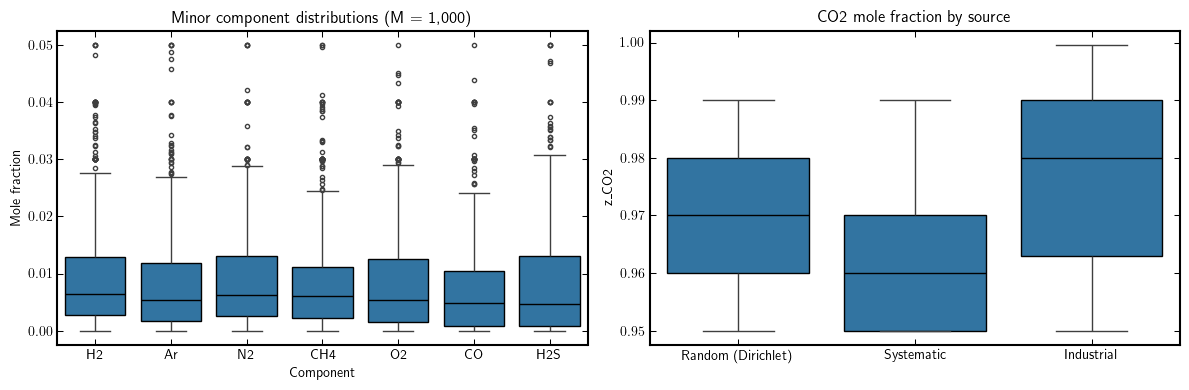

Mixture size distribution:
mixture_size
2     46
3    142
4    345
5    218
6    144
7     33
8     72
Name: count, dtype: int64

Feed source distribution:
feed_source
Random (Dirichlet)    700
Systematic            200
industrial_bound       60
industrial_range       40
Name: count, dtype: int64


In [6]:
# ── Diagnostics ───────────────────────────────────────────────────────────────
# Merge industrial sub-types into one label for plotting
plot_src = df_comp["feed_source"].replace(
    {"industrial_bound": "Industrial", "industrial_range": "Industrial"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: minor component distributions
minor_cols = ["H2", "Ar", "N2", "CH4", "O2", "CO", "H2S"]
plot_df = df_comp[minor_cols].melt(var_name="Component", value_name="Mole fraction")
plot_df = plot_df[plot_df["Mole fraction"] > 0]
sns.boxplot(data=plot_df, x="Component", y="Mole fraction",
            ax=axes[0], linewidth=1.0, fliersize=3,
            boxprops=dict(edgecolor="black"), medianprops=dict(color="black"))
axes[0].set_title(f"Minor component distributions (M = {len(df_comp):,})")
axes[0].set_ylabel("Mole fraction")
ps.apply_axis_style(axes[0])

# Right: CO2 fraction by source (Industrial = bound + range merged)
co2_df = pd.DataFrame({"CO2": df_comp["CO2"], "feed_source": plot_src})
sns.boxplot(data=co2_df, x="feed_source", y="CO2", ax=axes[1],
            order=["Random (Dirichlet)", "Systematic", "Industrial"],
            linewidth=1.0, fliersize=3,
            boxprops=dict(edgecolor="black"), medianprops=dict(color="black"))
axes[1].set_title("CO2 mole fraction by source")
axes[1].set_xlabel("")
axes[1].set_ylabel("z_CO2")
ps.apply_axis_style(axes[1])

plt.tight_layout()
ps.save_plot(fig, "pool_overview", folder=str(OUTPUT_DIR))
plt.show()

print(f"Mixture size distribution:")
print(df_comp["mixture_size"].value_counts().sort_index())
print(f"\nFeed source distribution:")
print(df_comp["feed_source"].value_counts())

In [7]:
elapsed = time.perf_counter() - notebook_start
print(f"Notebook runtime: {elapsed:.1f} s")

Notebook runtime: 9.2 s
